# Fractional-orbital warning-time analysis

This notebook composes the PASSES orbital, guidance and sensor-geometry
modules into the single comparison a fractional orbital profile exists to
raise: **between the same two points, how much warning does each trajectory
concede to a ground sensor network, and what does it cost to concede less?**

## What this is, and what it is not

This is a **strategic-stability analysis**, of the kind published openly in
the arms-control literature. Everything below is line-of-sight geometry
against publicly documented radar locations, driven by textbook two-body
mechanics (Regan, *Re-Entry Vehicle Dynamics*; Siouris, *Missile Guidance
and Control Systems*).

It deliberately models none of what would make a detection prediction:
transmit power, aperture, waveform, search-fence orientation, radar cross
section, track-initiation criteria, or the latency between a first return
and a decision. Every warning number here is therefore an **upper bound**,
and a generous one — "above the horizon" is necessary for detection and
nowhere near sufficient.

Radar mask elevations are **assumed at 5°**, not published. That assumption
is load-bearing for exactly the low-altitude case this notebook is about, so
§6 sweeps it rather than leaving it buried.

## 1. Configuration: the launch package

The scenario is not written in this notebook. It is loaded from a
**launch package** — a versioned, unit-annotated TOML document that states
everything chosen about a run and nothing derivable from those choices, so
that the file plus a version of the repository reproduces the run exactly.

Point `PACKAGE` at a different file to analyse a different scenario; nothing
below this cell needs to change.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from passes.geodesy import GeodeticPosition, great_circle_range, WGS84_MEAN_RADIUS
from passes.guidance.lofting import lofting_trade, optimum_burnout_angle
from passes.orbital.fobs import fractional_insertion
from passes.orbital.radar import EARLY_WARNING_SITES, RadarSite, coverage
from passes.orbital.scenario import (
    ballistic_trajectory,
    fobs_trajectory,
    warning_comparison,
)
from passes.orbital.warning import visibility_radius
from passes.systems.package import LaunchPackage, load_package

PACKAGE = "../packages/fobs-reference.toml"

package = load_package(PACKAGE)
print(package.summary())

fractional-orbital reference
  launch       +51.80, +59.50 (launch site)
  aimpoints    aimpoint
  architecture fractional-orbital-single
  burnout fpa  minimum-energy
  vehicle      beta=20,000 kg/m2, L/D=0, IMU=aviation
  sensors      framework default network
  objectives   warning_time, burnout_speed


A package validates on load. Units are in the key names (`latitude_deg`,
`parking_altitude_m`), vocabularies are closed and checked against the code,
and **unknown keys are refused** — which matters more than it sounds,
because in TOML a bare key written after a `[table]` header belongs to that
table, not to the document root. The first draft of the reference package
set `arrival_time_s` after `[vehicle]` and silently got the default; the
loader now catches that.

In [2]:
LAUNCH = package.launch
TARGET = package.aimpoints[0]
PARKING_ALTITUDE = package.profile.parking_altitude
RADAR_MASK_DEG = 5.0
SAMPLES = 600
EARTH_ROTATION = True

separation = great_circle_range(LAUNCH, TARGET)
print(f"launch  {np.rad2deg(LAUNCH.latitude):+7.2f} N  {np.rad2deg(LAUNCH.longitude):+8.2f} E")
print(f"target  {np.rad2deg(TARGET.latitude):+7.2f} N  {np.rad2deg(TARGET.longitude):+8.2f} E")
print(f"great-circle separation: {separation/1e3:,.0f} km "
      f"({np.rad2deg(separation/WGS84_MEAN_RADIUS):.1f} deg of arc)")

launch   +51.80 N    +59.50 E
target   +38.90 N    -77.00 E
great-circle separation: 9,084 km (81.7 deg of arc)


## 2. The sensor network

Approximate, published positions of long-standing early-warning
installations. No claim is made about operational status, tasking or
orientation — and the horizon circles below are what a site *could* see
geometrically, not what it is looking at.

In [3]:
sites = tuple(
    RadarSite(s.name, s.position, np.deg2rad(RADAR_MASK_DEG), s.note)
    for s in EARLY_WARNING_SITES
)

print(f"{'site':20s} {'lat':>7} {'lon':>8}   horizon radius (km)")
print(f"{'':20s} {'':>7} {'':>8}   {'@150 km':>9} {'@1300 km':>9}")
for s in sites:
    low = float(visibility_radius(150e3, s.mask_elevation)) / 1e3
    high = float(visibility_radius(1300e3, s.mask_elevation)) / 1e3
    print(f"{s.name:20s} {np.rad2deg(s.position.latitude):7.1f} "
          f"{np.rad2deg(s.position.longitude):8.1f}   {low:9.0f} {high:9.0f}")

site                     lat      lon   horizon radius (km)
                                          @150 km  @1300 km
Pituffik (Thule)        76.6    -68.3         920      3244
Clear                   64.3   -149.2         920      3244
Fylingdales             54.4     -0.7         920      3244
Cavalier                48.7    -97.9         920      3244
Cape Cod                41.8    -70.5         920      3244
Beale                   39.1   -121.4         920      3244
Eglin                   30.6    -86.2         920      3244
Shariki                 40.8    140.3         920      3244
Kwajalein                8.7    167.7         920      3244
Kürecik                 38.3     37.8         920      3244
Deveselu                44.3     24.4         920      3244
Redzikowo               54.5     17.1         920      3244
Globus II/III           70.4     31.1         920      3244


### Why altitude dominates

A site's visibility radius depends on the target's altitude and on nothing
else — not its speed, size, or heading. And it grows roughly as $\sqrt{h}$,
so the difference between a lofted ballistic apogee and a low parking orbit
is not marginal.

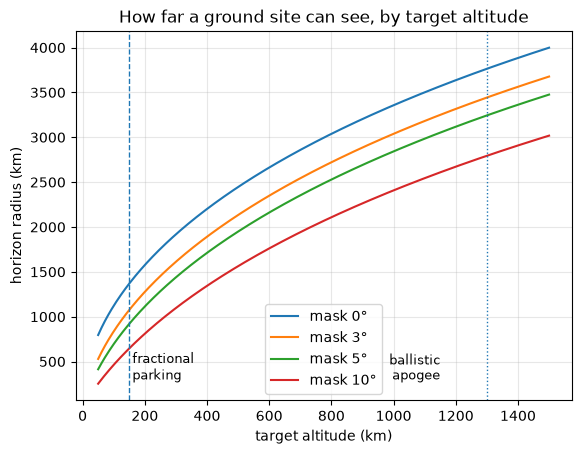

In [4]:
altitudes = np.linspace(50e3, 1500e3, 400)
for mask_deg in (0.0, 3.0, 5.0, 10.0):
    plt.plot(altitudes / 1e3,
             visibility_radius(altitudes, np.deg2rad(mask_deg)) / 1e3,
             label=f"mask {mask_deg:.0f}°")
plt.axvline(150, linestyle="--", linewidth=1)
plt.axvline(1300, linestyle=":", linewidth=1)
plt.text(160, 300, "fractional\nparking", fontsize=9)
plt.text(1150, 300, "ballistic\napogee", fontsize=9, ha="right")
plt.xlabel("target altitude (km)")
plt.ylabel("horizon radius (km)")
plt.title("How far a ground site can see, by target altitude")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. The two profiles

Both start at the launch site and end at the aimpoint. The **ballistic** arc
takes the short great circle on a Keplerian conic; the **fractional
orbital** profile takes the long way at low altitude, which is what produces
an approach from the reversed bearing.

In [5]:
comparison = warning_comparison(
    LAUNCH, TARGET,
    flight_path_angle=package.profile.burnout_flight_path_angle,
    parking_altitude=PARKING_ALTITUDE,
    sites=sites,
    samples=SAMPLES,
    earth_rotation=EARTH_ROTATION,
)

rows = [
    ("range angle (deg)", np.rad2deg(comparison.ballistic.range_angle),
     np.rad2deg(comparison.fobs.range_angle)),
    ("apogee (km)", comparison.ballistic.apogee / 1e3, comparison.fobs.apogee / 1e3),
    ("flight time (min)", comparison.ballistic.flight_time / 60,
     comparison.fobs.flight_time / 60),
    ("burnout speed (m/s)", comparison.ballistic.burnout_speed,
     comparison.fobs.burnout_speed),
    ("sites detecting", len(comparison.ballistic_coverage.detecting_sites),
     len(comparison.fobs_coverage.detecting_sites)),
    ("warning time (min)", comparison.ballistic_coverage.warning_time / 60,
     comparison.fobs_coverage.warning_time / 60),
]
print(f"{'':24s} {'ballistic':>12} {'fractional':>12}")
for name, b, f in rows:
    print(f"{name:24s} {b:12.1f} {f:12.1f}")
print()
print(f"first detection: {comparison.ballistic_coverage.first_detecting_site} "
      f"vs {comparison.fobs_coverage.first_detecting_site}")
print(f"warning removed:   {comparison.warning_reduction/60:+.1f} min")
print(f"flight time paid:  {comparison.flight_time_penalty/60:+.1f} min")

                            ballistic   fractional
range angle (deg)                79.0        285.0
apogee (km)                    1298.8        150.0
flight time (min)                29.7         69.1
burnout speed (m/s)            6975.5       7818.3
sites detecting                   6.0          1.0
warning time (min)               27.3          4.6

first detection: Globus II/III vs Eglin
warning removed:   +22.7 min
flight time paid:  +39.4 min


### Ground tracks

Plotted on a plain equirectangular grid — no coastlines, since the analysis
is purely geometric and a basemap would imply more precision than the
spherical model has. Circles are each site's horizon at the *fractional*
parking altitude, which is the demanding case.

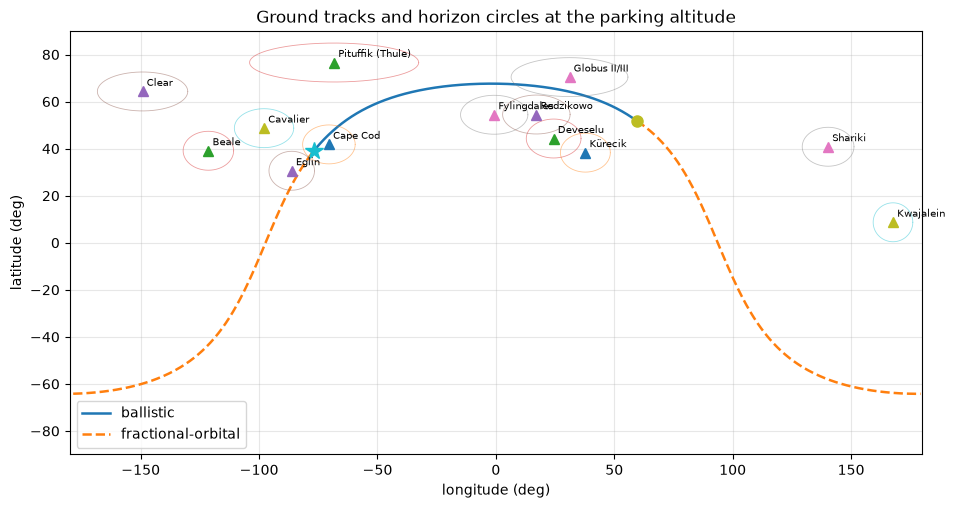

In [6]:
def track_degrees(trajectory):
    # Sub-vehicle track in degrees, with dateline wraps broken by NaN.
    lat = np.array([np.rad2deg(p.latitude) for p in trajectory.subpoints])
    lon = np.array([np.rad2deg(p.longitude) for p in trajectory.subpoints])
    lon = np.where(np.abs(np.diff(lon, prepend=lon[0])) > 180, np.nan, lon)
    return lon, lat


fig, ax = plt.subplots(figsize=(11, 5.5))
for traj, style in ((comparison.ballistic, "-"), (comparison.fobs, "--")):
    lon, lat = track_degrees(traj)
    ax.plot(lon, lat, style, linewidth=1.8, label=traj.label)

radius_deg = np.rad2deg(
    float(visibility_radius(PARKING_ALTITUDE, np.deg2rad(RADAR_MASK_DEG)))
    / WGS84_MEAN_RADIUS
)
angle = np.linspace(0, 2 * np.pi, 181)
for s in sites:
    slat, slon = np.rad2deg(s.position.latitude), np.rad2deg(s.position.longitude)
    ax.plot(slon, slat, "^", markersize=7)
    ax.plot(slon + radius_deg * np.cos(angle) / max(np.cos(np.deg2rad(slat)), 0.2),
            slat + radius_deg * np.sin(angle), linewidth=0.6, alpha=0.45)
    ax.annotate(s.name, (slon, slat), fontsize=7, xytext=(3, 4),
                textcoords="offset points")

ax.plot(np.rad2deg(LAUNCH.longitude), np.rad2deg(LAUNCH.latitude), "o", markersize=8)
ax.plot(np.rad2deg(TARGET.longitude), np.rad2deg(TARGET.latitude), "*", markersize=13)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel("longitude (deg)"); ax.set_ylabel("latitude (deg)")
ax.set_title("Ground tracks and horizon circles at the parking altitude")
ax.grid(alpha=0.3); ax.legend(loc="lower left")
plt.show()

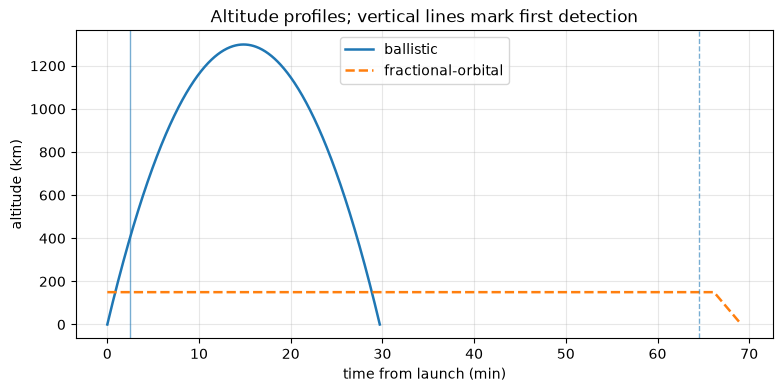

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for traj, style in ((comparison.ballistic, "-"), (comparison.fobs, "--")):
    ax.plot(traj.times / 60, traj.altitudes / 1e3, style, linewidth=1.8, label=traj.label)
for cov, traj, style in ((comparison.ballistic_coverage, comparison.ballistic, "-"),
                         (comparison.fobs_coverage, comparison.fobs, "--")):
    if cov.detected:
        ax.axvline(cov.first_detection_time / 60, linestyle=style, linewidth=1, alpha=0.6)
ax.set_xlabel("time from launch (min)")
ax.set_ylabel("altitude (km)")
ax.set_title("Altitude profiles; vertical lines mark first detection")
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 4. Which site sees what, and when

The network's warning is set by whichever *single* site detects first, which
is why adding sensors away from the approach corridor changes nothing. The
chart below shows per-site first-detection times.

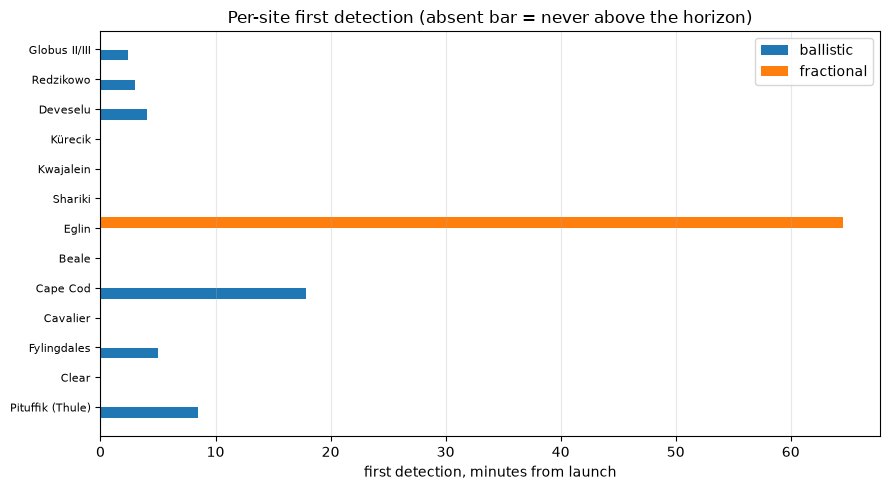

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
names = [s.name for s in sites]
y = np.arange(len(names))
for offset, (cov, traj, label) in enumerate(
    ((comparison.ballistic_coverage, comparison.ballistic, "ballistic"),
     (comparison.fobs_coverage, comparison.fobs, "fractional")),
):
    times = [
        cov.windows[n].first_detection_time / 60 if cov.windows[n].detected else np.nan
        for n in names
    ]
    ax.barh(y + (offset - 0.5) * 0.38, times, height=0.36, label=label)
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("first detection, minutes from launch")
ax.set_title("Per-site first detection (absent bar = never above the horizon)")
ax.grid(alpha=0.3, axis="x"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Objective functions

There is no single "optimal" profile, because the objectives disagree. This
section sweeps the ballistic burnout flight-path angle from strongly
depressed through minimum-energy to strongly lofted, and prices each
against three objectives:

- **minimise warning** — what a short-warning attack wants;
- **minimise energy** — the burnout speed, i.e. throw-weight for a given booster;
- **minimise flight time**.

The minimum-energy angle $\gamma^\* = \pi/4 - \theta/4$ is marked. Recall
from `passes.guidance.lofting` that $\partial R/\partial\gamma$ is *exactly
zero* there, so it is also the trajectory least sensitive to boost pitch
error — a fourth objective that this sweep does not plot but that the
accuracy chain cares about.

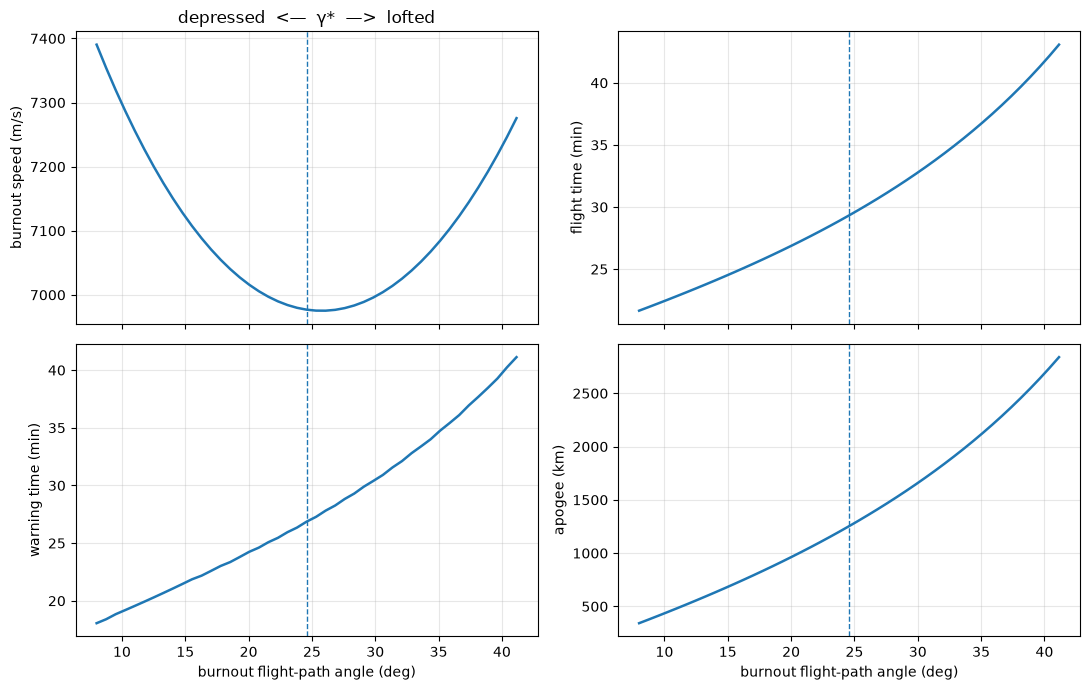

In [9]:
theta = float(separation / WGS84_MEAN_RADIUS)
gamma_star = optimum_burnout_angle(theta)
gammas = np.deg2rad(np.linspace(8.0, 2 * np.rad2deg(gamma_star) - 8.0, 45))

sweep = []
for gamma in gammas:
    c = warning_comparison(LAUNCH, TARGET, flight_path_angle=float(gamma),
                           parking_altitude=PARKING_ALTITUDE, sites=sites,
                           samples=250, earth_rotation=EARTH_ROTATION)
    sweep.append((
        np.rad2deg(gamma),
        c.ballistic.burnout_speed,
        c.ballistic.flight_time / 60,
        c.ballistic_coverage.warning_time / 60 if c.ballistic_coverage.detected else np.nan,
        c.ballistic.apogee / 1e3,
    ))
sweep = np.array(sweep)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
labels = ["burnout speed (m/s)", "flight time (min)", "warning time (min)", "apogee (km)"]
for ax, column, label in zip(axes.ravel(), range(1, 5), labels):
    ax.plot(sweep[:, 0], sweep[:, column], linewidth=1.8)
    ax.axvline(np.rad2deg(gamma_star), linestyle="--", linewidth=1)
    ax.set_ylabel(label); ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("burnout flight-path angle (deg)")
axes[0, 0].set_title("depressed  <—  γ*  —>  lofted")
plt.tight_layout(); plt.show()

### Reading the sweep

Three things are worth noticing, and the third is the one that makes this a
genuine trade rather than a ranking:

1. **Burnout speed is minimised at $\gamma^\*$** and rises symmetrically on
   both sides — the two conjugate angles cost identical energy.
2. **Flight time rises monotonically with loft.** Depression is what buys
   warning-time compression, and it does so on the ballistic arc alone,
   without any orbital profile.
3. **Warning time does not simply follow apogee.** It is set by when some
   site first clears its mask, which depends on where the sites are relative
   to the track — so the curve can be flat over a wide band and then step.

In [10]:
trade = lofting_trade(theta, np.deg2rad(12.0))
print(f"range angle          {np.rad2deg(trade.range_angle):.1f} deg")
print(f"gamma*               {np.rad2deg(trade.optimum_angle):.2f} deg")
print(f"depressed / lofted   {np.rad2deg(trade.depressed_angle):.2f} / "
      f"{np.rad2deg(trade.lofted_angle):.2f} deg  (conjugates)")
print(f"shared burnout speed {trade.burnout_speed:,.0f} m/s "
      f"({trade.speed_penalty*100:.1f}% above minimum)")
print(f"flight times         {trade.depressed_time/60:.1f} / {trade.lofted_time/60:.1f} min"
      f"   ratio {trade.time_ratio:.2f}")

range angle          81.7 deg
gamma*               24.58 deg
depressed / lofted   12.00 / 37.15 deg  (conjugates)
shared burnout speed 7,241 m/s (3.0% above minimum)
flight times         23.9 / 40.9 min   ratio 1.71


## 6. Fractional-orbital configuration

Two knobs matter for the fractional profile: the parking altitude, which
sets horizon exposure directly, and the assumed radar mask, which is the
least defensible number in the whole model.

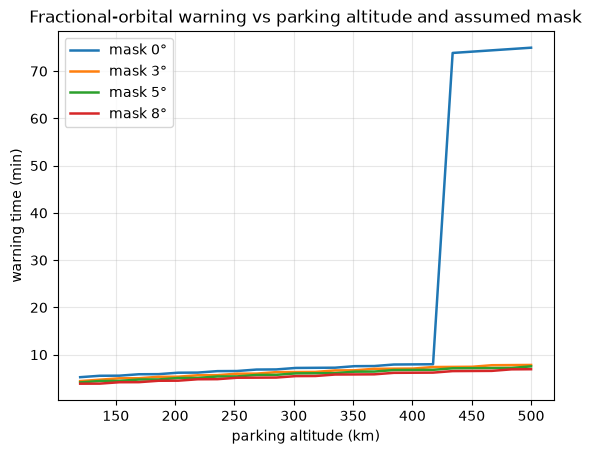

In [11]:
parking = np.linspace(120e3, 500e3, 24)
by_mask = {}
for mask_deg in (0.0, 3.0, 5.0, 8.0):
    masked = tuple(
        RadarSite(s.name, s.position, np.deg2rad(mask_deg), s.note)
        for s in EARLY_WARNING_SITES
    )
    warnings = []
    for altitude in parking:
        traj = fobs_trajectory(LAUNCH, TARGET, parking_altitude=float(altitude),
                               samples=250, earth_rotation=EARTH_ROTATION)
        cov = coverage(traj.times, traj.altitudes, traj.subpoints, masked)
        warnings.append(cov.warning_time / 60 if cov.detected else np.nan)
    by_mask[mask_deg] = np.array(warnings)

for mask_deg, warnings in by_mask.items():
    plt.plot(parking / 1e3, warnings, linewidth=1.8, label=f"mask {mask_deg:.0f}°")
plt.xlabel("parking altitude (km)")
plt.ylabel("warning time (min)")
plt.title("Fractional-orbital warning vs parking altitude and assumed mask")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The spread between mask assumptions is the honest uncertainty band on every
warning number in this notebook. It is not small, and it is largest exactly
where the fractional profile operates.

## 7. Is the insertion actually *fractional*?

The defining property is that perigee sits at or below the entry interface,
so the vehicle cannot complete a revolution and the deorbit burn is a
targeting manoeuvre rather than the thing that brings it down.

In [12]:
radius = WGS84_MEAN_RADIUS + PARKING_ALTITUDE
circular = np.sqrt(3.986004418e14 / radius)
print(f"circular speed at {PARKING_ALTITUDE/1e3:.0f} km: {circular:,.0f} m/s\n")
print(f"{'deficit':>8} {'insertion':>11} {'perigee alt':>12} {'fractional':>11} {'revs to entry':>14}")
for deficit in (0.0, 0.005, 0.01, 0.02, 0.05, 0.10):
    result = fractional_insertion(
        radius, circular * (1 - deficit), WGS84_MEAN_RADIUS + 100e3
    )
    revs = f"{result.revolutions_to_entry:.3f}" if result.is_fractional else "—"
    print(f"{deficit*100:7.1f}% {circular*(1-deficit):11,.0f} "
          f"{(result.perigee_radius - WGS84_MEAN_RADIUS)/1e3:12,.0f} "
          f"{str(result.is_fractional):>11} {revs:>14}")

circular speed at 150 km: 7,818 m/s

 deficit   insertion  perigee alt  fractional  revs to entry
    0.0%       7,818          150       False              —
    0.5%       7,779           21        True          0.213
    1.0%       7,740         -104        True          0.144
    2.0%       7,662         -347        True          0.099
    5.0%       7,427       -1,009        True          0.061
   10.0%       7,036       -1,932        True          0.041


Half a percent below circular is already enough to put perigee inside the
atmosphere. Fractional insertion is a small perturbation on an orbital one —
which is why the distinction is as much about intent as about energy, and
why it was historically an arms-control question rather than an engineering
one.

## 8. Worst case: searching the launch geometry

Everything so far analyses *one* launch site. The operationally interesting
question is the other way round: **across all the places a launch could come
from, which geometry concedes the least warning against this target?** That
is a search over the sphere, and it is cheap enough to do exhaustively.

The objective is deliberately explicit. `warning_time` is the one the
package names; the cells below also report burnout speed and flight time at
each candidate, because a geometry that removes warning while demanding an
unattainable booster is not a worst case, it is an infeasible one.

In [13]:
# Coarse sweep over launch latitude and longitude, holding the target fixed.
lat_grid = np.arange(-70.0, 75.1, 10.0)
lon_grid = np.arange(-180.0, 180.0, 12.0)

warning_grid = np.full((lat_grid.size, lon_grid.size), np.nan)
speed_grid = np.full_like(warning_grid, np.nan)
time_grid = np.full_like(warning_grid, np.nan)

for i, lat in enumerate(lat_grid):
    for j, lon in enumerate(lon_grid):
        candidate = GeodeticPosition(np.deg2rad(lat), np.deg2rad(lon), 0.0, "candidate")
        arc = great_circle_range(candidate, TARGET) / WGS84_MEAN_RADIUS
        if not 0.05 < arc < np.pi - 0.05:
            continue
        try:
            traj = fobs_trajectory(candidate, TARGET, parking_altitude=PARKING_ALTITUDE,
                                   samples=180, earth_rotation=EARTH_ROTATION)
            cov = coverage(traj.times, traj.altitudes, traj.subpoints, sites)
        except ValueError:
            continue
        warning_grid[i, j] = cov.warning_time / 60 if cov.detected else 0.0
        speed_grid[i, j] = traj.burnout_speed
        time_grid[i, j] = traj.flight_time / 60

finite = np.isfinite(warning_grid)
print(f"evaluated {finite.sum()} of {warning_grid.size} candidate launch points")
print(f"warning spans {np.nanmin(warning_grid):.1f} to {np.nanmax(warning_grid):.1f} min")

evaluated 450 of 450 candidate launch points
warning spans 0.0 to 86.4 min


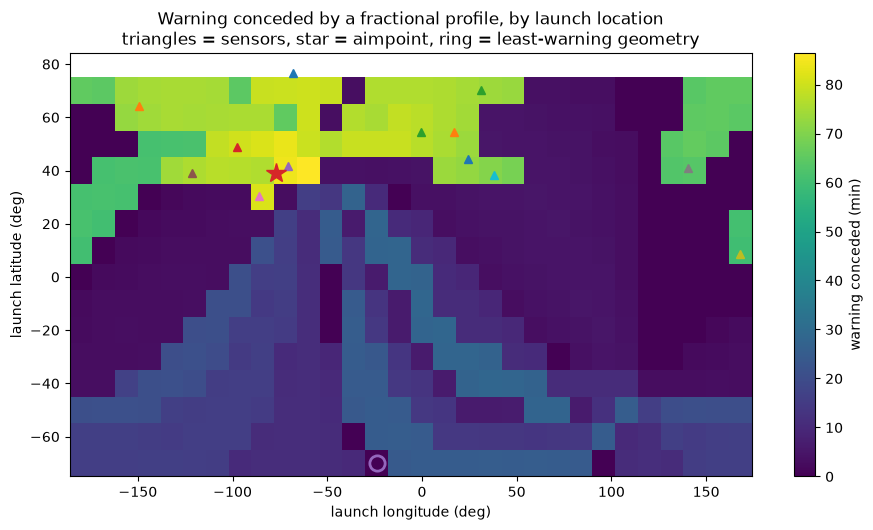

least-warning launch geometry: -70 N, -24 E
  warning        0.0 min
  burnout speed  7,818 m/s
  flight time    60.1 min


In [14]:
fig, ax = plt.subplots(figsize=(11, 5.5))
mesh = ax.pcolormesh(lon_grid, lat_grid, warning_grid, shading="nearest")
fig.colorbar(mesh, ax=ax, label="warning conceded (min)")

for s_ in sites:
    ax.plot(np.rad2deg(s_.position.longitude), np.rad2deg(s_.position.latitude),
            "^", markersize=6)
ax.plot(np.rad2deg(TARGET.longitude), np.rad2deg(TARGET.latitude), "*", markersize=15)

flat = np.nanargmin(np.where(finite, warning_grid, np.inf))
wi, wj = np.unravel_index(flat, warning_grid.shape)
ax.plot(lon_grid[wj], lat_grid[wi], "o", markersize=11, markerfacecolor="none",
        markeredgewidth=2)
ax.set_xlabel("launch longitude (deg)"); ax.set_ylabel("launch latitude (deg)")
ax.set_title("Warning conceded by a fractional profile, by launch location\n"
             "triangles = sensors, star = aimpoint, ring = least-warning geometry")
plt.show()

print(f"least-warning launch geometry: {lat_grid[wi]:+.0f} N, {lon_grid[wj]:+.0f} E")
print(f"  warning        {warning_grid[wi, wj]:.1f} min")
print(f"  burnout speed  {speed_grid[wi, wj]:,.0f} m/s")
print(f"  flight time    {time_grid[wi, wj]:.1f} min")

### Reading the worst case

The minimum is **not** simply "as far from the sensors as possible". Warning
is set by the last stretch of the approach, so what matters is the bearing
the vehicle arrives on and which horizon circles that final leg crosses —
which is why the map has structure rather than a single smooth gradient
away from the radar sites.

Two cautions before this number is quoted anywhere:

- The grid is coarse, and warning time is **not smooth** in launch position:
  it steps as the track enters and leaves individual horizon circles. A
  finer grid will find a lower minimum, and the depth of that minimum is a
  property of the sensor spacing rather than of the physics.
- A zero-warning cell means *no site in this list ever sees the trajectory*,
  which is a statement about a thirteen-site model, not about the world.

In [15]:
# The trade at the extremes: least-warning geometry against the package's own.
best = GeodeticPosition(np.deg2rad(lat_grid[wi]), np.deg2rad(lon_grid[wj]), 0.0, "worst case")
rows = []
for label, origin in (("package launch", LAUNCH), ("least-warning", best)):
    c = warning_comparison(origin, TARGET, parking_altitude=PARKING_ALTITUDE,
                           sites=sites, samples=300, earth_rotation=EARTH_ROTATION)
    rows.append((label,
                 c.fobs_coverage.warning_time / 60 if c.fobs_coverage.detected else 0.0,
                 c.ballistic_coverage.warning_time / 60,
                 c.fobs.burnout_speed, c.fobs.flight_time / 60,
                 len(c.fobs_coverage.detecting_sites)))

print(f"{'':16s} {'FOBS warn':>10} {'ball warn':>10} {'V_bo':>9} {'flight':>8} {'sites':>6}")
for label, fw, bw, v, t, n in rows:
    print(f"{label:16s} {fw:10.1f} {bw:10.1f} {v:9,.0f} {t:8.1f} {n:6d}")

                  FOBS warn  ball warn      V_bo   flight  sites
package launch          4.6       27.3     7,818     69.1      1
least-warning           0.0        6.9     7,818     60.1      0


## 9. Sweeping a package

Because the scenario is a file, a sweep is a sweep over *packages* rather
than over loose keyword arguments — and `with_profile` returns a copy, so a
sweep cannot contaminate the baseline it started from.

In [16]:
print(f"{'parking (km)':>13} {'warning (min)':>14} {'flight (min)':>13} {'V_bo (m/s)':>11}")
for altitude in (120e3, 150e3, 200e3, 300e3, 500e3):
    variant = package.with_profile(parking_altitude=float(altitude))
    traj = fobs_trajectory(variant.launch, variant.aimpoints[0],
                           parking_altitude=variant.profile.parking_altitude,
                           samples=250, earth_rotation=EARTH_ROTATION)
    cov = coverage(traj.times, traj.altitudes, traj.subpoints, sites)
    warn = cov.warning_time / 60 if cov.detected else 0.0
    print(f"{altitude/1e3:13.0f} {warn:14.1f} {traj.flight_time/60:13.1f} "
          f"{traj.burnout_speed:11,.0f}")

# The baseline is untouched.
assert package.profile.parking_altitude == PARKING_ALTITUDE
print(f"\nbaseline package unchanged: parking_altitude_m = {package.profile.parking_altitude:,.0f}")

 parking (km)  warning (min)  flight (min)  V_bo (m/s)
          120            4.1          68.7       7,836
          150            4.4          69.1       7,818
          200            5.1          70.0       7,788
          300            6.0          71.6       7,730
          500            7.5          75.0       7,617

baseline package unchanged: parking_altitude_m = 150,000


## 8. Limitations

Stated plainly, because a notebook that produces maps and minute-counts
invites being read as a prediction.

- **Geometry only.** No power-aperture, cross-section, waveform, search
  fence, track initiation or decision latency. Warning times are upper
  bounds.
- **Masks are assumed**, not published — see §6 for what that is worth.
- **No Earth rotation** under the fractional parking arc. The planet turns
  ~22° per low revolution, which would move the sub-vehicle track east-west
  by up to a couple of thousand kilometres. That changes *which* site
  detects first more than *when*, but it is a real omission.
- **Spherical Earth** throughout the trajectory geometry, matching the rest
  of the framework's guidance modules.
- **No boost phase.** The trajectory begins at burnout; a real boost is
  itself detectable by infrared sensors long before any radar sees the
  vehicle, and that channel is not modelled at all. For a short-warning
  analysis this is the single largest omission.
- **Site list is illustrative**, approximate, and says nothing about
  operational status or tasking. A "zero warning" result means no site *in
  this thirteen-site model* sees the trajectory, which is not the same
  claim.
- **The worst-case search is coarse**, and warning time steps rather than
  varying smoothly with launch position, so a finer grid finds a lower
  minimum whose depth reflects sensor spacing rather than physics.
- **Earth rotation is now carried** in the ground track, and both profiles
  lead their aim point accordingly — 7.4° for the ballistic arc, 17.3° for
  the fractional one. Without that lead a fractional profile misses by
  ~1500 km. The orbit plane is still treated as fixed in inertial space,
  which is right to the extent that it does not precess inside one
  revolution.